# Two-qubit gate with resonator workflow

This notebook implements the current version of `Two qubit gate with resonator work flow.md` using the repository Hamiltonian helpers and the existing `DQDlabframe.ipynb` conventions.

Concrete choices fixed for this version:
- symmetric DQDs for now
- finite preparation detuning `epsilon_1 = epsilon_2 = 50 GHz`, converted explicitly into the model's `μ eV` detuning parameter
- DQD1-only lab-frame EDSR drive during the preparation stage
- `omega_drive = B_z / ħ` and `Omega_drive = 2pi 	imes 100` MHz
- square, instantaneous detuning pulses between the preparation and gate stages
- `π/2` preparation time calibrated numerically from the driven prep evolution rather than fixed by a guessed analytic factor

Because the resonator gate time is on the microsecond scale while the prep drive carries a GHz-scale carrier, the notebook treats the workflow as three separate stages:
1. GHz-resolved full lab-frame prep at finite detuning
2. instantaneous pulse to `ε = 0` and full source-notebook resonator gate evolution
3. instantaneous pulse back to finite detuning for readout bookkeeping


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
from qutip import basis, qeye, tensor

repo_root = Path.cwd().resolve()
for candidate in [repo_root, *repo_root.parents]:
    if (candidate / "python").exists() and (candidate / "pyproject.toml").exists():
        repo_root = candidate
        break

python_root = repo_root / "python"
if str(python_root) not in sys.path:
    sys.path.insert(0, str(python_root))

from helpers import DQDsystem
from helpers import HBAR_UEV_US, TWO_PI, single_dqd_qubit_splitting

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

In [2]:
def ghz_to_uev(ghz):
    """Convert a frequency given in GHz into the model's detuning energy in μ eV."""
    return HBAR_UEV_US * TWO_PI * ghz * 1_000.0


def lab_frame_product_state(photon_max, spin1="up", spin2="down"):
    spin_index = {"up": 0, "down": 1}
    psi1 = basis([2, 2], [spin_index[spin1], 0])
    psi2 = basis([2, 2], [spin_index[spin2], 0])
    return tensor(basis(photon_max, 0), psi1, psi2)


def spin_populations(states, spin_index):
    proj_up = basis(2, 0) * basis(2, 0).dag()
    proj_down = basis(2, 1) * basis(2, 1).dag()
    rho_spin = [qt.ket2dm(state).ptrace(spin_index) for state in states]
    p_up = np.array([qt.expect(proj_up, rho) for rho in rho_spin], dtype=float)
    p_down = np.array([qt.expect(proj_down, rho) for rho in rho_spin], dtype=float)
    return p_up, p_down


def first_half_population_crossing(p_up):
    balance = p_up - 0.5
    crossings = np.where(np.sign(balance[:-1]) != np.sign(balance[1:]))[0]
    if len(crossings):
        return int(crossings[0] + 1)
    return int(np.argmin(np.abs(balance)))


def bare_two_spin_populations(states):
    rho_spin_pair = [qt.ket2dm(state).ptrace([1, 3]) for state in states]
    labels = {
        "uu": tensor(basis(2, 0), basis(2, 0)),
        "ud": tensor(basis(2, 0), basis(2, 1)),
        "du": tensor(basis(2, 1), basis(2, 0)),
        "dd": tensor(basis(2, 1), basis(2, 1)),
    }
    return {
        key: np.array([qt.expect(ket * ket.dag(), rho) for rho in rho_spin_pair], dtype=float)
        for key, ket in labels.items()
    }


def charge_right_probability(states, charge_index):
    proj_right = basis(2, 0) * basis(2, 0).dag()
    rho_charge = [qt.ket2dm(state).ptrace(charge_index) for state in states]
    return np.array([qt.expect(proj_right, rho) for rho in rho_charge], dtype=float)

In [5]:
# Symmetric DQD parameters inherited from DQDlabframe.ipynb
tc = 80.0
bx = 20.0
Bz = 50.0
wc = TWO_PI * 5.5e3
gc = TWO_PI * 50.0
photon_max = 10

# Workflow-specific inputs fixed in the markdown discussion
epsilon_prepare_ghz = 50.0
epsilon_prepare_uev = ghz_to_uev(epsilon_prepare_ghz)
omega_drive = Bz / HBAR_UEV_US
Omega_drive = TWO_PI * 100.0

dqd = DQDsystem(
    tc=tc,
    bx=bx,
    Bz=Bz,
    Vac0=0.0,
    wc=wc,
    gc=gc,
    photon_max=photon_max,
    epsilon_idle=0.0,
)

prep_qubit_split_ghz = single_dqd_qubit_splitting(dqd, epsilon_prepare_uev)
gate_time_us = dqd.iSWAP_gate_time()
r_sigma, r_tau = dqd.dispersive_ratios()

print({
    "epsilon_prepare_uev": epsilon_prepare_uev,
    "omega_drive_rad_per_us": omega_drive,
    "Omega_drive_rad_per_us": Omega_drive,
    "prep_qubit_split_GHz": prep_qubit_split_ghz,
    "gate_time_us": gate_time_us,
    "|g_sigma/d_sigma|": r_sigma,
    "|g_tau/d_tau|": r_tau,
})

{'epsilon_prepare_uev': 206.78338483020013, 'omega_drive_rad_per_us': 75963.37239980637, 'Omega_drive_rad_per_us': 628.3185307179587, 'prep_qubit_split_GHz': 79.58321327026711, 'gate_time_us': np.float64(103.72813272010966), '|g_sigma/d_sigma|': np.float64(0.001055764711263123), '|g_tau/d_tau|': np.float64(0.0014775555324608616)}


## Step 1: calibrate the finite-detuning `π/2` preparation

The workflow asks for a lab-frame EDSR preparation on DQD1 at finite detuning. Here we keep both DQDs at the same finite detuning, drive only DQD1 with

`V_drive = Omega_drive cos(omega_drive t) sigma_x otimes I_charge`,

and choose the shortest pulse duration that brings the reduced DQD1 spin populations as close as possible to 50/50 in the full driven evolution.

{'prep_time_ns': 12.9, 'p_up_at_prep_time': np.float64(0.812457213565154), 'p_down_at_prep_time': np.float64(0.18754278643484634)}


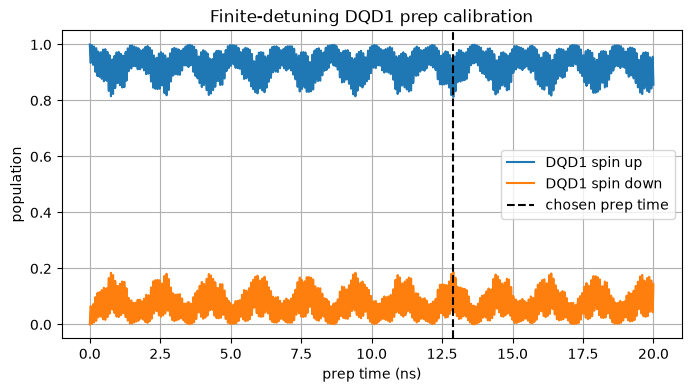

In [6]:
psi0_lab = lab_frame_product_state(photon_max, spin1="up", spin2="down")
H_drive1 = tensor(qeye(photon_max), dqd.sx1)
H_prep_static = dqd.H_static + epsilon_prepare_uev * dqd.H_eps1_op + epsilon_prepare_uev * dqd.H_eps2_op

def drive_coeff(t, Omega_drive, omega_drive):
    return Omega_drive * np.cos(omega_drive * t)

prep_scan_ns = np.linspace(0.0, 20.0, 801)
prep_scan_us = prep_scan_ns / 1000.0
prep_args = {"Omega_drive": Omega_drive, "omega_drive": omega_drive}
prep_opts = {"nsteps": 200000, "atol": 1e-9, "rtol": 1e-9, "store_states": True}

res_prep = qt.mesolve(
    [H_prep_static, [H_drive1, drive_coeff]],
    psi0_lab,
    prep_scan_us,
    c_ops=[],
    e_ops=[],
    args=prep_args,
    options=prep_opts,
)

p_up_prep, p_down_prep = spin_populations(res_prep.states, spin_index=1)
prep_idx = first_half_population_crossing(p_up_prep)
prep_time_us = float(prep_scan_us[prep_idx])
prep_time_ns = 1_000.0 * prep_time_us
psi_after_prep = res_prep.states[prep_idx]

print({
    "prep_time_ns": prep_time_ns,
    "p_up_at_prep_time": p_up_prep[prep_idx],
    "p_down_at_prep_time": p_down_prep[prep_idx],
})

plt.plot(prep_scan_ns, p_up_prep, label="DQD1 spin up")
plt.plot(prep_scan_ns, p_down_prep, label="DQD1 spin down")
plt.axvline(prep_time_ns, color="black", linestyle="--", label="chosen prep time")
plt.xlabel("prep time (ns)")
plt.ylabel("population")
plt.title("Finite-detuning DQD1 prep calibration")
plt.legend();

## Steps 2 and 3: square pulse to `ε = 0`, then run the resonator gate

The square detuning pulse is treated as instantaneous, so the prep state is passed directly into the resonator gate Hamiltonian at `ε_1 = ε_2 = 0`. The gate stage follows the original source notebook and uses the full photon + two-DQD Hamiltonian together with the same dispersive gate-time estimate.

In [ ]:
gate_samples = 1201
gate_tlist_us = np.linspace(0.0, gate_time_us, gate_samples)
gate_opts = {"nsteps": 500000, "atol": 1e-8, "rtol": 1e-8, "store_states": True}

res_gate = qt.mesolve(
    [dqd.H_static],
    psi_after_prep,
    gate_tlist_us,
    c_ops=[],
    e_ops=[],
    options=gate_opts,
)

psi_after_gate = res_gate.states[-1]
p_up_gate, p_down_gate = spin_populations(res_gate.states, spin_index=1)
two_spin_pops = bare_two_spin_populations(res_gate.states)
charge_right_1 = charge_right_probability(res_gate.states, charge_index=2)
charge_right_2 = charge_right_probability(res_gate.states, charge_index=4)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(gate_tlist_us, p_up_gate, label="DQD1 spin up")
axes[0].plot(gate_tlist_us, p_down_gate, label="DQD1 spin down")
axes[0].set_xlabel("gate time (μs)")
axes[0].set_ylabel("population")
axes[0].set_title("DQD1 spin populations during gate")
axes[0].legend()

for label, values in two_spin_pops.items():
    axes[1].plot(gate_tlist_us, values, label=label)
axes[1].set_xlabel("gate time (μs)")
axes[1].set_ylabel("population")
axes[1].set_title("Bare two-spin populations")
axes[1].legend()

axes[2].plot(gate_tlist_us, charge_right_1, label="DQD1 charge-right")
axes[2].plot(gate_tlist_us, charge_right_2, label="DQD2 charge-right")
axes[2].set_xlabel("gate time (μs)")
axes[2].set_ylabel("probability")
axes[2].set_title("Charge-right occupancy during gate")
axes[2].legend()

plt.tight_layout()

readout_summary = {
    "prep_time_ns": prep_time_ns,
    "gate_time_us": gate_time_us,
    "final_DQD1_spin_up": float(p_up_gate[-1]),
    "final_DQD1_spin_down": float(p_down_gate[-1]),
    "final_charge_right_1": float(charge_right_1[-1]),
    "final_charge_right_2": float(charge_right_2[-1]),
}
readout_summary

## Step 4: pulse back to finite detuning for readout

With square pulses, the return to `ε_1 = ε_2 = 50` GHz is an instantaneous parameter change at the end of the gate stage, so the post-gate state is reused directly for readout bookkeeping. If a later workflow version needs a finite ramp or a finite readout hold, add a third `mesolve` segment here.

In [ ]:
sequence_times_ns = np.array([0.0, prep_time_ns, prep_time_ns, prep_time_ns + 1_000.0 * gate_time_us])
eps_profile_ghz = np.array([epsilon_prepare_ghz, epsilon_prepare_ghz, 0.0, 0.0])
drive_profile_mhz = np.array([Omega_drive / TWO_PI, Omega_drive / TWO_PI, 0.0, 0.0])

fig, ax = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
ax[0].step(sequence_times_ns, eps_profile_ghz, where="post")
ax[0].set_ylabel("detuning (GHz)")
ax[0].set_title("Workflow pulse schedule")

ax[1].step(sequence_times_ns, drive_profile_mhz, where="post")
ax[1].set_ylabel(r"$\Omega_{drive} / 2\pi$ (MHz)")
ax[1].set_xlabel("sequence time (ns)")

plt.tight_layout()

### Follow-up items

The external workflow note ends by pointing out that the two DQDs should eventually be made asymmetric. This notebook keeps them symmetric exactly as requested for the first implementation. The next extension should lift that assumption by introducing independent parameter sets for DQD1 and DQD2, together with possibly different preparation frequencies and readout projections.